In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Everything is working!")

Matplotlib is building the font cache; this may take a moment.


Everything is working!


In [2]:
import pandas as pd
import glob
import os

In [3]:
# Path to all CSV files
csv_files = glob.glob("../data/raw/*.csv")

# Check how many files were found
print(f"Number of CSV files found: {len(csv_files)}")

# Display file names
for file in csv_files:
    print(file)

Number of CSV files found: 12
../data/raw\202410-divvy-tripdata.csv
../data/raw\202411-divvy-tripdata.csv
../data/raw\202412-divvy-tripdata.csv
../data/raw\202501-divvy-tripdata.csv
../data/raw\202502-divvy-tripdata.csv
../data/raw\202503-divvy-tripdata.csv
../data/raw\202504-divvy-tripdata.csv
../data/raw\202505-divvy-tripdata.csv
../data/raw\202506-divvy-tripdata.csv
../data/raw\202507-divvy-tripdata.csv
../data/raw\202508-divvy-tripdata.csv
../data/raw\202509-divvy-tripdata.csv


In [4]:
# Read all CSV files into a list of DataFrames
df_list = [pd.read_csv(file) for file in csv_files]

# Combine all DataFrames into one
cyclistic_df = pd.concat(df_list, ignore_index=True)

# Display the first 5 rows
cyclistic_df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,4422E707103AA4FF,electric_bike,2024-10-14 03:26:04.083,2024-10-14 03:32:56.535,NaN,NaN,NaN,NaN,41.96,-87.65,41.98,-87.67,member
1,19DB722B44CBE82F,electric_bike,2024-10-13 19:33:38.926,2024-10-13 19:39:04.490,NaN,NaN,NaN,NaN,41.98,-87.67,41.97,-87.66,member
2,20AE2509FD68C939,electric_bike,2024-10-13 23:40:48.522,2024-10-13 23:48:02.339,NaN,NaN,NaN,NaN,41.97,-87.66,41.95,-87.65,member
3,D0F17580AB9515A9,electric_bike,2024-10-14 02:13:41.602,2024-10-14 02:25:40.057,NaN,NaN,NaN,NaN,41.95,-87.65,41.96,-87.65,member
4,A114A483941288D1,electric_bike,2024-10-13 19:26:41.383,2024-10-13 19:28:18.560,NaN,NaN,NaN,NaN,41.98,-87.67,41.98,-87.67,member


In [5]:
# Basic information about the dataset

print("Shape of dataset:")
print(cyclistic_df.shape)

print("\nColumn names:")
print(cyclistic_df.columns)

print("\nData types:")
cyclistic_df.info()

Shape of dataset:
(5539521, 13)

Column names:
Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual'],
      dtype='str')

Data types:
<class 'pandas.DataFrame'>
RangeIndex: 5539521 entries, 0 to 5539520
Data columns (total 13 columns):
 #   Column              Dtype  
---  ------              -----  
 0   ride_id             str    
 1   rideable_type       str    
 2   started_at          str    
 3   ended_at            str    
 4   start_station_name  str    
 5   start_station_id    str    
 6   end_station_name    str    
 7   end_station_id      str    
 8   start_lat           float64
 9   start_lng           float64
 10  end_lat             float64
 11  end_lng             float64
 12  member_casual       str    
dtypes: float64(4), str(9)
memory usage: 549.4 MB


In [6]:
# Count missing values in each column

missing_values = cyclistic_df.isnull().sum()

print(missing_values)

ride_id                     0
rideable_type               0
started_at                  0
ended_at                    0
start_station_name    1129029
start_station_id      1129029
end_station_name      1175835
end_station_id        1175835
start_lat                   0
start_lng                   0
end_lat                  5442
end_lng                  5442
member_casual               0
dtype: int64


In [7]:
# Convert text columns to datetime

cyclistic_df['started_at'] = pd.to_datetime(cyclistic_df['started_at'])
cyclistic_df['ended_at'] = pd.to_datetime(cyclistic_df['ended_at'])

# Verify conversion
cyclistic_df[['started_at', 'ended_at']].dtypes

started_at    datetime64[us]
ended_at      datetime64[us]
dtype: object

In [8]:
# Create ride duration in minutes

cyclistic_df["ride_length"] = (
    cyclistic_df["ended_at"] - cyclistic_df["started_at"]
).dt.total_seconds() / 60

# Check the first few values
cyclistic_df["ride_length"].head()

0     6.874200
1     5.426067
2     7.230283
3    11.974250
4     1.619617
Name: ride_length, dtype: float64

In [9]:
# Check for invalid ride durations

print("Negative rides:", (cyclistic_df["ride_length"] < 0).sum())
print("Zero-minute rides:", (cyclistic_df["ride_length"] == 0).sum())

print("\nSummary:")
cyclistic_df["ride_length"].describe()

Negative rides: 43
Zero-minute rides: 0

Summary:


count    5.539521e+06
mean     1.605884e+01
std      5.462121e+01
min     -5.602170e+01
25%      5.412667e+00
50%      9.451883e+00
75%      1.661140e+01
max      1.574900e+03
Name: ride_length, dtype: float64

In [10]:
# Remove rides with negative duration

cyclistic_df = cyclistic_df[cyclistic_df["ride_length"] >= 0]

# Verify
print("New shape:", cyclistic_df.shape)
print("Negative rides remaining:",
      (cyclistic_df["ride_length"] < 0).sum())

New shape: (5539478, 14)
Negative rides remaining: 0


In [11]:
# Create useful date columns

cyclistic_df["date"] = cyclistic_df["started_at"].dt.date
cyclistic_df["month"] = cyclistic_df["started_at"].dt.month_name()
cyclistic_df["day"] = cyclistic_df["started_at"].dt.day_name()
cyclistic_df["year"] = cyclistic_df["started_at"].dt.year
cyclistic_df["hour"] = cyclistic_df["started_at"].dt.hour

# Preview the new columns
cyclistic_df[
    ["started_at", "date", "month", "day", "year", "hour"]
].head()

,started_at,date,month,day,year,hour
0,2024-10-14 03:26:04.083,2024-10-14,October,Monday,2024,3
1,2024-10-13 19:33:38.926,2024-10-13,October,Sunday,2024,19
2,2024-10-13 23:40:48.522,2024-10-13,October,Sunday,2024,23
3,2024-10-14 02:13:41.602,2024-10-14,October,Monday,2024,2
4,2024-10-13 19:26:41.383,2024-10-13,October,Sunday,2024,19


In [12]:
# Set correct weekday order

day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

cyclistic_df["day"] = pd.Categorical(
    cyclistic_df["day"],
    categories=day_order,
    ordered=True
)

In [13]:
# Count rides by user type

cyclistic_df["member_casual"].value_counts()

member_casual
member    3543343
casual    1996135
Name: count, dtype: int64

In [14]:
# Percentage of rides by user type

ride_percentages = (
    cyclistic_df["member_casual"]
    .value_counts(normalize=True) * 100
).round(2)

print(ride_percentages)

member_casual
member    63.97
casual    36.03
Name: proportion, dtype: float64


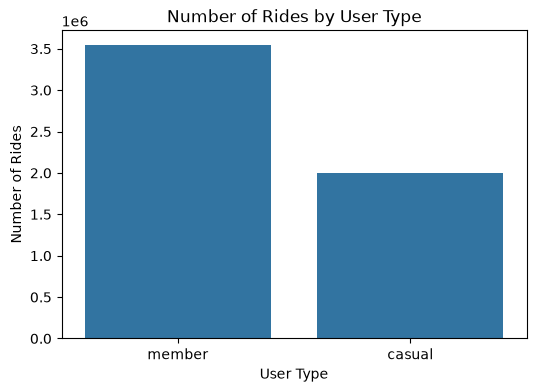

In [15]:
# Import seaborn (if not already imported)
import seaborn as sns
import matplotlib.pyplot as plt

# Count rides by user type
plt.figure(figsize=(6,4))

sns.countplot(
    data=cyclistic_df,
    x="member_casual"
)

plt.title("Number of Rides by User Type")
plt.xlabel("User Type")
plt.ylabel("Number of Rides")

plt.show()

In [16]:
# Count rides by day and user type

rides_by_day = (
    cyclistic_df
    .groupby(["day", "member_casual"])
    .size()
    .reset_index(name="number_of_rides")
)

rides_by_day

,day,member_casual,number_of_rides
0,Monday,casual,231883
1,Monday,member,509378
2,Tuesday,casual,232200
3,Tuesday,member,578063
4,Wednesday,casual,219831
5,Wednesday,member,541681
6,Thursday,casual,251510
7,Thursday,member,557863
8,Friday,casual,313602
9,Friday,member,517717


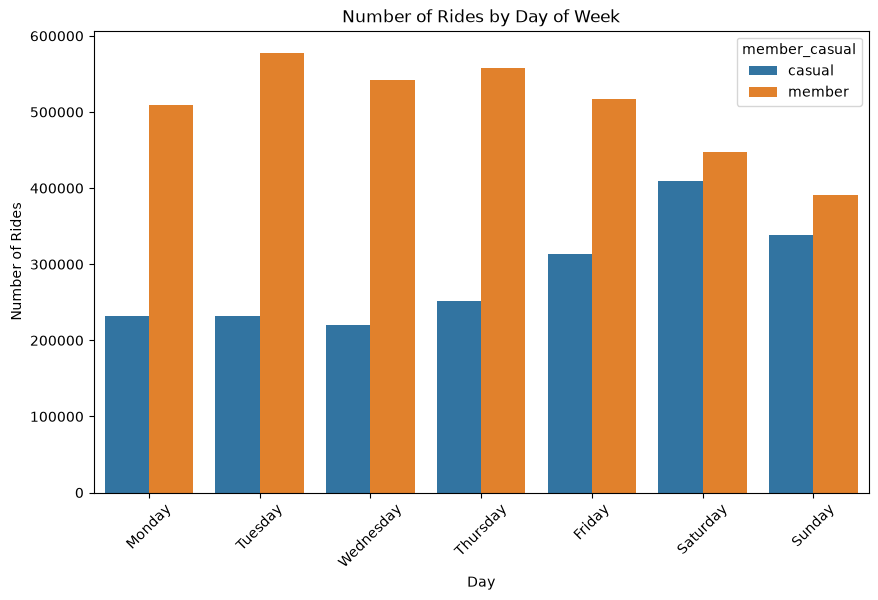

In [17]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=rides_by_day,
    x="day",
    y="number_of_rides",
    hue="member_casual"
)

plt.title("Number of Rides by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Rides")

plt.xticks(rotation=45)

plt.show()

In [18]:
# Average ride length by user type

average_ride = (
    cyclistic_df
    .groupby("member_casual")["ride_length"]
    .mean()
    .round(2)
)

average_ride

member_casual
casual    22.96
member    12.17
Name: ride_length, dtype: float64

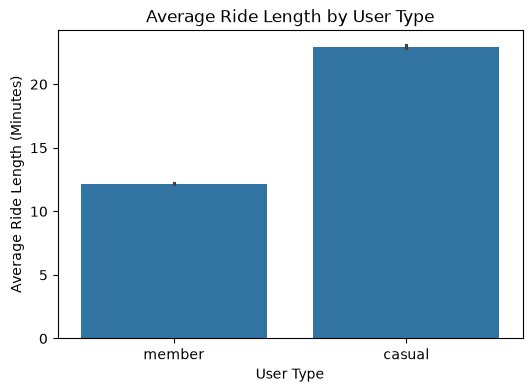

In [19]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=cyclistic_df,
    x="member_casual",
    y="ride_length",
    estimator="mean"
)

plt.title("Average Ride Length by User Type")
plt.xlabel("User Type")
plt.ylabel("Average Ride Length (Minutes)")

plt.show()

In [20]:
# Count rides by month and user type

rides_by_month = (
    cyclistic_df
    .groupby(["month", "member_casual"])
    .size()
    .reset_index(name="number_of_rides")
)

rides_by_month

,month,member_casual,number_of_rides
0,April,casual,109239
1,April,member,262137
2,August,casual,337878
3,August,member,452439
4,December,casual,38406
5,December,member,140006
6,February,casual,27757
7,February,member,124144
8,January,casual,24124
9,January,member,114527


In [21]:
month_order = [
    "October", "November", "December",
    "January", "February", "March",
    "April", "May", "June",
    "July", "August", "September"
]

cyclistic_df["month"] = pd.Categorical(
    cyclistic_df["month"],
    categories=month_order,
    ordered=True
)

In [22]:
rides_by_month = (
    cyclistic_df
    .groupby(["month", "member_casual"])
    .size()
    .reset_index(name="number_of_rides")
)

rides_by_month

,month,member_casual,number_of_rides
0,October,casual,216452
1,October,member,399840
2,November,casual,93039
3,November,member,241960
4,December,casual,38406
5,December,member,140006
6,January,casual,24124
7,January,member,114527
8,February,casual,27757
9,February,member,124144


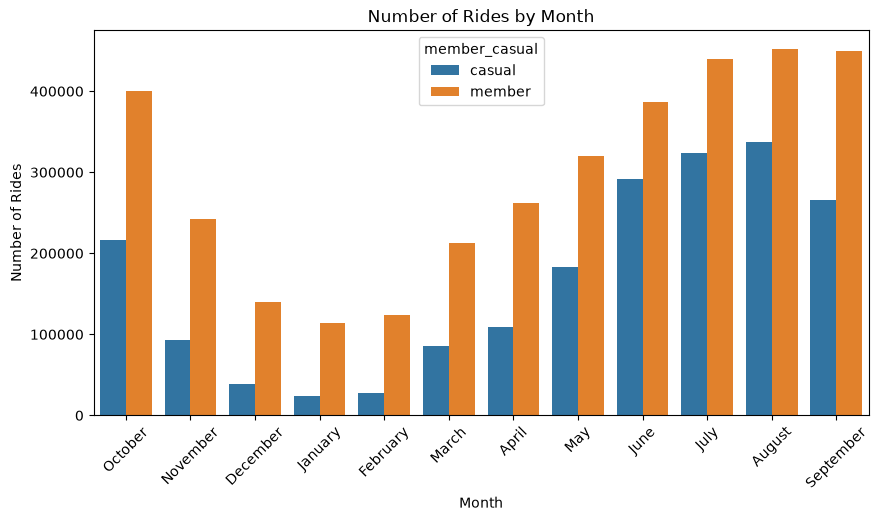

In [23]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=rides_by_month,
    x="month",
    y="number_of_rides",
    hue="member_casual"
)

plt.title("Number of Rides by Month")
plt.xlabel("Month")
plt.ylabel("Number of Rides")
plt.xticks(rotation=45)

plt.show()

In [24]:
average_day = (
    cyclistic_df
    .groupby(["day", "member_casual"])["ride_length"]
    .mean()
    .reset_index()
)

average_day

,day,member_casual,ride_length
0,Monday,casual,22.503904
1,Monday,member,11.697159
2,Tuesday,casual,19.916822
3,Tuesday,member,11.755424
4,Wednesday,casual,19.159854
5,Wednesday,member,11.637546
6,Thursday,casual,20.301188
7,Thursday,member,11.768405
8,Friday,casual,22.802009
9,Friday,member,12.134431


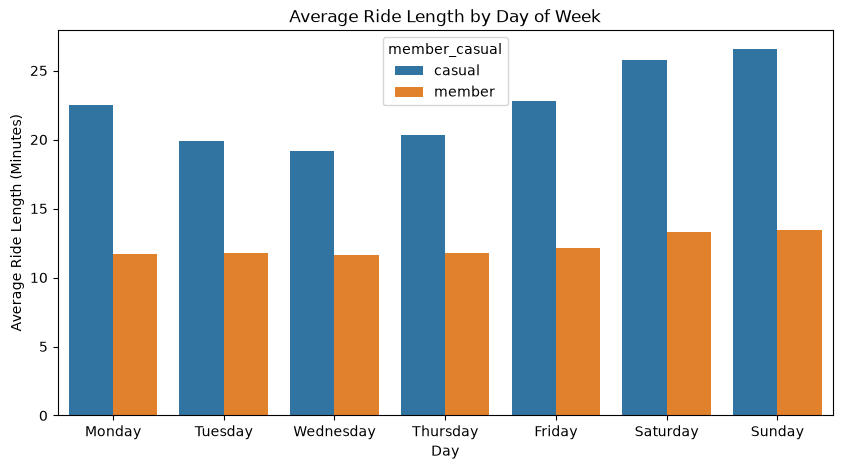

In [25]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=average_day,
    x="day",
    y="ride_length",
    hue="member_casual"
)

plt.title("Average Ride Length by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Ride Length (Minutes)")

plt.show()

In [26]:
rides_by_hour = (
    cyclistic_df
    .groupby(["hour", "member_casual"])
    .size()
    .reset_index(name="number_of_rides")
)

rides_by_hour

,hour,member_casual,number_of_rides
0,0,casual,37882
1,0,member,32072
2,1,casual,24537
3,1,member,19942
4,2,casual,16080
5,2,member,11884
6,3,casual,8966
7,3,member,8119
8,4,casual,7103
9,4,member,8876


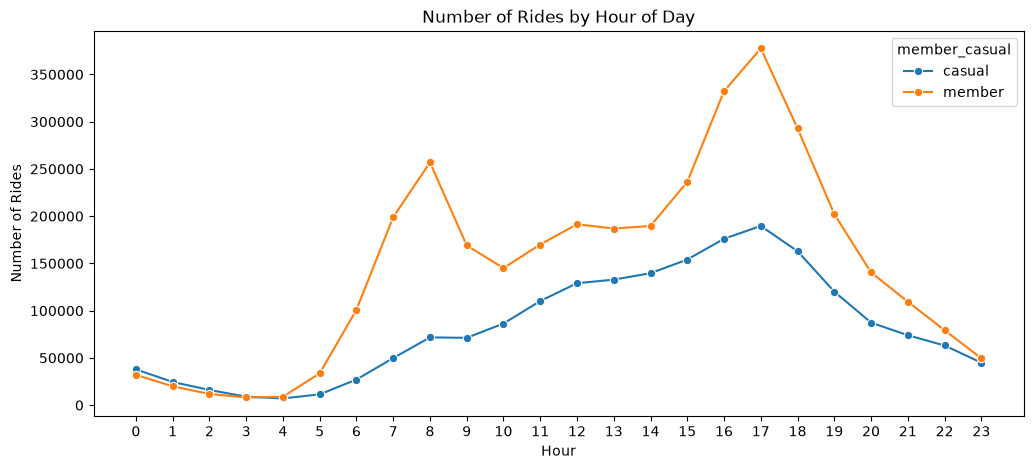

In [27]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=rides_by_hour,
    x="hour",
    y="number_of_rides",
    hue="member_casual",
    marker="o"
)

plt.title("Number of Rides by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Rides")

plt.xticks(range(24))

plt.show()

# Key Findings

### 1. Members use Cyclistic more frequently.
- Members accounted for approximately **64%** of all rides.
- Casual riders accounted for approximately **36%** of all rides.

### 2. Casual riders take longer trips.
- Average ride length for casual riders: **22.96 minutes**
- Average ride length for members: **12.17 minutes**

### 3. Casual riders prefer weekends.
- Casual rides peak on **Saturday** and **Sunday**.
- Member rides remain relatively consistent throughout the week.

### 4. Ridership increases during summer.
- Both user types recorded the highest number of rides between **June and September**.

### 5. Members commute during peak hours.
- Members show strong ride peaks around **8 AM** and **5–6 PM**.
- Casual riders have a more gradual increase throughout the day.

# Business Insights

The analysis indicates that annual members and casual riders use Cyclistic bikes for different purposes.

Annual members appear to use bikes primarily for commuting. Their rides are shorter, highly consistent, and concentrated during weekday rush hours.

Casual riders behave more like recreational customers. They take significantly longer rides, especially on weekends and during warmer months, suggesting leisure or tourism-related usage.

Because casual riders already make extensive use of the service, they represent the strongest opportunity for membership conversion.

# Recommendations

Based on the analysis, Cyclistic should consider the following strategies:

1. Promote annual memberships to casual riders through weekend promotions and seasonal campaigns.

2. Introduce discounted membership trials during peak riding months such as June through September.

3. Offer incentives to frequent casual riders, including ride credits or discounted annual memberships.

4. Highlight the cost savings and convenience of annual memberships in marketing campaigns.

5. Develop targeted advertising aimed at recreational riders and tourists who frequently use the service.

# Conclusion

This analysis demonstrates clear behavioral differences between annual members and casual riders.

Members primarily use Cyclistic bikes for commuting, while casual riders ride longer and more frequently for recreational purposes.

These findings suggest that Cyclistic should focus its marketing efforts on converting casual riders into annual members through targeted promotions, seasonal campaigns, and membership incentives.

Implementing these recommendations can increase annual memberships and contribute to the company's long-term growth.